# Stage 6 - Hardware retuning (6A vs 6B)

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "src", "config.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("Project root (folder containing src/) not found")
    ROOT = parent
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.makedirs("results/figures", exist_ok=True)

In [2]:
import os, sys, json

import numpy as np
import matplotlib.pyplot as plt

from src import config as C
from src.stages import (make_device, mitigated, stage06_loader, stage06_gci, save_stage06)
from src.metrics import hellinger_fidelity
from src.pipeline_io import save_fig, nominal_parameters
from src.gci_model import target_gaussian_histogram

BLUE, RED, GREEN, GREY, ORANGE = "#1f4e8c", "#c0392b", "#27ae60", "#7f8c8d", "#e67e22"
np.set_printoptions(precision=4, suppress=True)

for n in C.REGISTER_SIZES:
    x_nom = nominal_parameters(n)
    print(f"{n}-qubit register  nominal commanded angles (deg): "
          f"theta = {np.round(np.rad2deg(x_nom[:n]), 2)}, "
          f"2*beta~ = {np.rad2deg(2 * x_nom[n]):.2f}, 2*alpha~ = {np.rad2deg(2 * x_nom[n + 1]):.2f}")

2-qubit register  nominal commanded angles (deg): theta = [ 90.   195.35], 2*beta~ = 80.85, 2*alpha~ = -13.86
3-qubit register  nominal commanded angles (deg): theta = [ 89.99  55.04 131.01], 2*beta~ = 80.85, 2*alpha~ = -5.94


In [3]:
devices = {n: make_device(n, "gci") for n in C.REGISTER_SIZES}
for n, (dev, x0, ref) in devices.items():
    s = dev.summary()
    print(f"=== {n}-qubit z-register GCI circuit on the mock device ===")
    print(f"  physical qubits used (logical -> physical): {s['logical_to_physical']}")
    print(f"  transpiled depth = {s['transpiled_depth']}, gates = {s['transpiled_gate_counts']}")
    print("  hidden control drift on those qubits (never shown to the optimisers):")
    for d in s["drift_per_logical_qubit"]:
        print(f"     logical q{d['logical_qubit']} -> physical Q{d['physical_qubit']}: "
              f"amplitude error {d['eps']:+.0%}, offset {d['delta_deg']:+.0f} deg")

=== 2-qubit z-register GCI circuit on the mock device ===
  physical qubits used (logical -> physical): [2, 1, 3]
  transpiled depth = 40, gates = {'rz': 24, 'sx': 20, 'cz': 8, 'measure': 3, 'barrier': 1}
  hidden control drift on those qubits (never shown to the optimisers):
     logical q0 -> physical Q2: amplitude error +14%, offset +10 deg
     logical q1 -> physical Q1: amplitude error -10%, offset -15 deg
     logical q2 -> physical Q3: amplitude error -11%, offset -12 deg
=== 3-qubit z-register GCI circuit on the mock device ===
  physical qubits used (logical -> physical): [3, 2, 4, 1]
  transpiled depth = 67, gates = {'rz': 36, 'sx': 33, 'cz': 14, 'measure': 4, 'barrier': 1}
  hidden control drift on those qubits (never shown to the optimisers):
     logical q0 -> physical Q3: amplitude error -11%, offset -12 deg
     logical q1 -> physical Q2: amplitude error +14%, offset +10 deg
     logical q2 -> physical Q4: amplitude error +10%, offset +14 deg
     logical q3 -> physical 

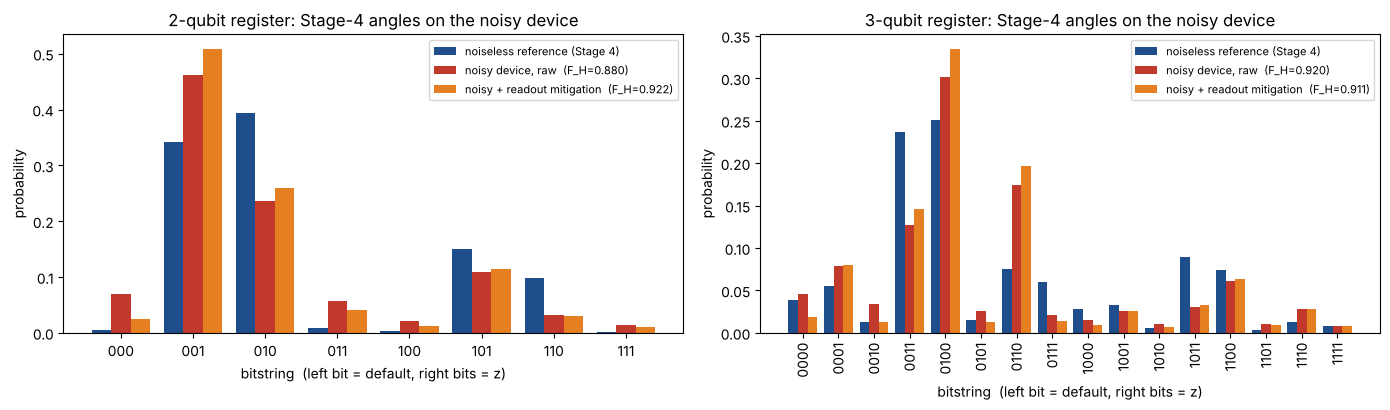

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
problem = {}
for ax, n in zip(axes, C.REGISTER_SIZES):
    dev, x0, ref = devices[n]
    A, M = mitigated(dev)
    raw = dev.run(x0, C.SHOTS_FINAL_CHECK, seed=11)
    rem = M.run(x0, C.SHOTS_FINAL_CHECK, seed=11)
    problem[n] = (hellinger_fidelity(raw, ref), hellinger_fidelity(rem, ref))
    k = np.arange(len(ref)); w = 0.27
    ax.bar(k - w, ref, w, color=BLUE, label="noiseless reference (Stage 4)")
    ax.bar(k, raw, w, color=RED, label=f"noisy device, raw  (F_H={problem[n][0]:.3f})")
    ax.bar(k + w, rem, w, color=ORANGE, label=f"noisy + readout mitigation  (F_H={problem[n][1]:.3f})")
    ax.set_xticks(k); ax.set_xticklabels([format(i, f"0{n+1}b") for i in k], rotation=90 if n == 3 else 0)
    ax.set_title(f"{n}-qubit register: Stage-4 angles on the noisy device")
    ax.set_xlabel("bitstring  (left bit = default, right bits = z)"); ax.set_ylabel("probability")
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig(fig, "stage06_problem_uncalibrated.png"); plt.show()

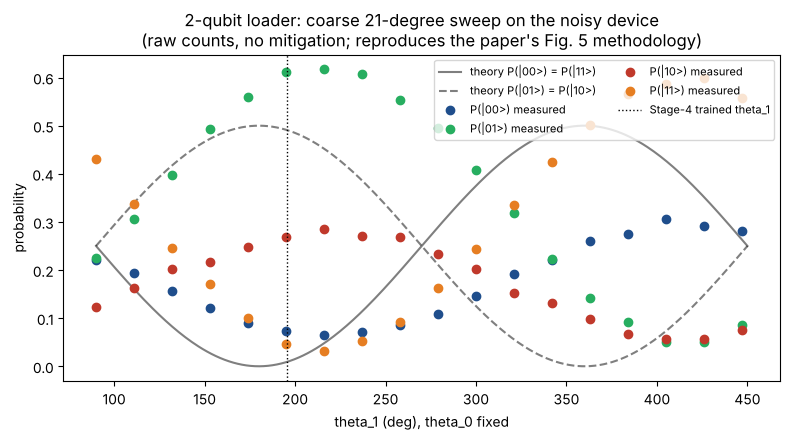

In [5]:
from src.device import NoisyDevice
ldev, lx0, lref = make_device(2, "loader")
thetas = np.deg2rad(np.arange(90, 451, 21))
xs = [np.array([lx0[0], t]) for t in thetas]
measured = np.array(ldev.run_many(xs, 4000, seed=5))
fine = np.deg2rad(np.linspace(90, 450, 300))
theory = np.array([ldev.ideal_probs(np.array([lx0[0], t])) for t in fine])

fig, ax = plt.subplots(figsize=(8, 4.5))
cols = [BLUE, GREEN, RED, ORANGE]
ax.plot(np.rad2deg(fine), theory[:, 0], color="k", lw=1.5, alpha=0.5, label="theory P(|00>) = P(|11>)")
ax.plot(np.rad2deg(fine), theory[:, 1], color="k", lw=1.5, ls="--", alpha=0.5, label="theory P(|01>) = P(|10>)")
for b in range(4):
    ax.plot(np.rad2deg(thetas), measured[:, b], "o", color=cols[b], label=f"P(|{b:02b}>) measured")
ax.axvline(np.rad2deg(lx0[1]) % 360 + (360 if np.rad2deg(lx0[1]) % 360 < 90 else 0), color="k", ls=":", lw=1,
           label="Stage-4 trained theta_1")
ax.set_xlabel("theta_1 (deg), theta_0 fixed"); ax.set_ylabel("probability")
ax.set_title("2-qubit loader: coarse 21-degree sweep on the noisy device\n(raw counts, no mitigation; reproduces the paper's Fig. 5 methodology)")
ax.legend(fontsize=8, ncol=2); plt.tight_layout()
save_fig(fig, "stage06_theta1_sweep_2q.png"); plt.show()

In [6]:
loader = {}
for n in C.REGISTER_SIZES:
    loader[n] = stage06_loader(n, verbose=True)
    print()

[2q loader] uncalibrated: F_H raw = 0.9193, with readout mitigation = 0.9595


   grid_6A       : F_H = 0.9618   circuit evaluations =   61
   bo_6B         : F_H = 0.9997   circuit evaluations =   40
   spsa_ablation : F_H = 0.9999   circuit evaluations =  308



[3q loader] uncalibrated: F_H raw = 0.9266, with readout mitigation = 0.8972


   grid_6A       : F_H = 0.9645   circuit evaluations =  191
   bo_6B         : F_H = 0.9998   circuit evaluations =   40
   spsa_ablation : F_H = 0.9998   circuit evaluations =  308



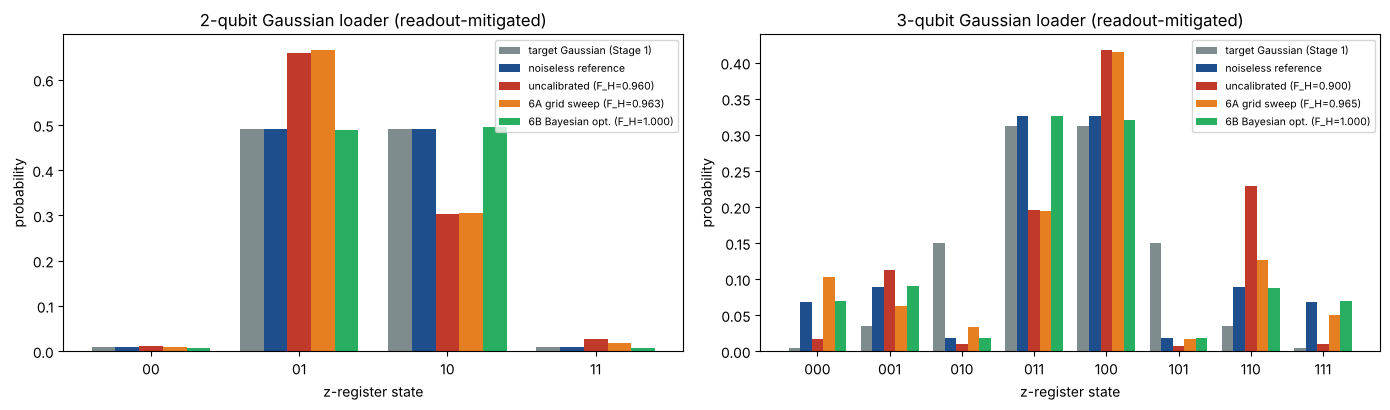

Note: the noiseless 3-qubit reference itself only reaches F_H = 0.783 against the ideal Gaussian --
that is the expressivity ceiling of the 3-parameter star ansatz found in Stage 4, not a noise effect.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, n in zip(axes, C.REGISTER_SIZES):
    summ, objs = loader[n]
    M, ref = objs["M"], objs["ref"]
    target = np.array(summ["target_gaussian"])
    series = [("target Gaussian (Stage 1)", target, GREY),
              ("noiseless reference", ref, BLUE),
              ("uncalibrated", M.run(objs["x0"], 20000, seed=3), RED),
              ("6A grid sweep", M.run(objs["grid"].x_best, 20000, seed=3), ORANGE),
              ("6B Bayesian opt.", M.run(objs["bo"].x_best, 20000, seed=3), GREEN)]
    k = np.arange(2 ** n); w = 0.16
    for i, (lab, p, c) in enumerate(series):
        f = "" if i < 2 else f" (F_H={hellinger_fidelity(p, ref):.3f})"
        ax.bar(k + (i - 2) * w, p, w, color=c, label=lab + f)
    ax.set_xticks(k); ax.set_xticklabels([format(i, f"0{n}b") for i in k])
    ax.set_title(f"{n}-qubit Gaussian loader (readout-mitigated)"); ax.set_xlabel("z-register state")
    ax.set_ylabel("probability"); ax.legend(fontsize=7.5)
plt.tight_layout(); save_fig(fig, "stage06_loader_distributions.png"); plt.show()

print("Note: the noiseless 3-qubit reference itself only reaches "
      f"F_H = {hellinger_fidelity(loader[3][1]['ref'], loader[3][0]['target_gaussian']):.3f} against the ideal Gaussian --")
print("that is the expressivity ceiling of the 3-parameter star ansatz found in Stage 4, not a noise effect.")

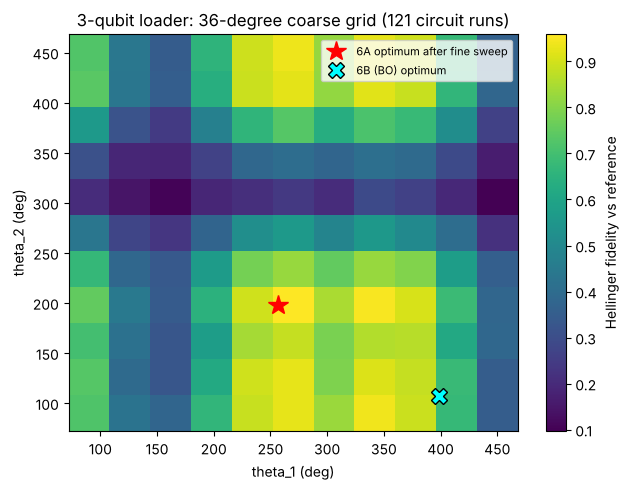

In [8]:
# The paper's 3-qubit coarse sweep as a landscape (like its Supplementary Fig. S12)
g3 = loader[3][1]["grid"]
land = g3.extra["landscape"]
ax1, ax2 = [np.rad2deg(a) for a in land["coarse_axes"]]
F = (1 - land["coarse_distance"] ** 2) ** 2
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(F.reshape(len(ax1), len(ax2)).T, origin="lower", aspect="auto", cmap="viridis",
               extent=[ax1[0] - 18, ax1[-1] + 18, ax2[0] - 18, ax2[-1] + 18])
bx = np.rad2deg(g3.x_best)
ax.plot(bx[1], bx[2], "r*", ms=15, label="6A optimum after fine sweep")
bb = np.rad2deg(loader[3][1]["bo"].x_best) % 360
bb = np.where(bb < 90, bb + 360, bb)
ax.plot(bb[1], bb[2], "X", color="cyan", mec="k", ms=12, label="6B (BO) optimum")
plt.colorbar(im, label="Hellinger fidelity vs reference")
ax.set_xlabel("theta_1 (deg)"); ax.set_ylabel("theta_2 (deg)")
ax.set_title("3-qubit loader: 36-degree coarse grid (121 circuit runs)")
ax.legend(fontsize=8, loc="upper right"); plt.tight_layout()
save_fig(fig, "stage06_loader_landscape_3q.png"); plt.show()

In [9]:
gci, params = {}, {}
for n in C.REGISTER_SIZES:
    summ, par, objs = stage06_gci(n, loader[n][1], verbose=True)
    gci[n], params[n] = (summ, objs), par
    print()

[2q GCI]    uncalibrated: F_H raw = 0.8801, with readout mitigation = 0.9225


   grid_6A             : F_H = 0.9389   circuit evaluations =  347
   auto_6B             : F_H = 0.9818   circuit evaluations =  204
   joint_spsa_ablation : F_H = 0.9820   circuit evaluations =  308
   joint_bo_ablation   : F_H = 0.9727   circuit evaluations =   70



[3q GCI]    uncalibrated: F_H raw = 0.9199, with readout mitigation = 0.9099


   grid_6A             : F_H = 0.9570   circuit evaluations =  477
   auto_6B             : F_H = 0.9943   circuit evaluations =  204
   joint_spsa_ablation : F_H = 0.9469   circuit evaluations =  308
   joint_bo_ablation   : F_H = 0.9637   circuit evaluations =   70



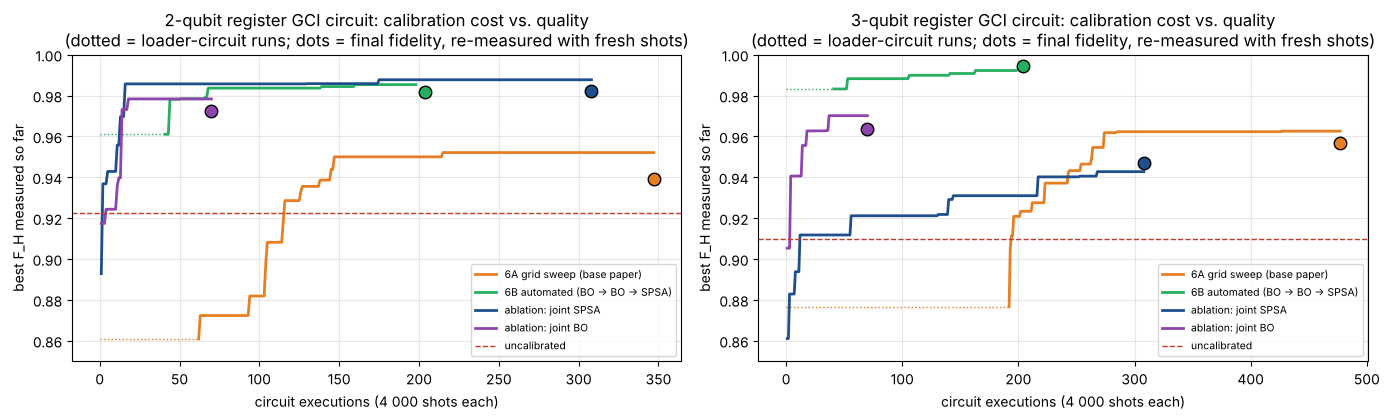

In [10]:
# Convergence: best objective found so far vs. number of circuit executions
labels = {"grid_6A": "6A grid sweep (base paper)", "auto_6B": "6B automated (BO -> BO -> SPSA)",
          "joint_spsa_ablation": "ablation: joint SPSA", "joint_bo_ablation": "ablation: joint BO"}
colors = {"grid_6A": ORANGE, "auto_6B": GREEN, "joint_spsa_ablation": BLUE, "joint_bo_ablation": "#8e44ad"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for ax, n in zip(axes, C.REGISTER_SIZES):
    summ, objs = gci[n]
    lobj = loader[n][1]
    # (offset, history-on-the-GCI-circuit): the loader-calibration runs of 6A / 6B are spent
    # on the stand-alone loader circuit, so they are shown as an offset, not as GCI values
    curves = {"grid_6A": (lobj["grid"].n_evals, objs["grid"].history),
              "auto_6B": (lobj["bo"].n_evals, objs["auto"].history[lobj["bo"].n_evals:]),
              "joint_spsa_ablation": (0, objs["spsa"].history),
              "joint_bo_ablation": (0, objs["bo"].history)}
    for key, (off, h) in curves.items():
        F_best = (1 - np.minimum.accumulate(np.asarray(h)) ** 2) ** 2
        x = off + np.arange(1, len(F_best) + 1)
        ax.plot(x, F_best, color=colors[key], lw=2, label=labels[key])
        if off:
            ax.plot([0, off], [F_best[0]] * 2, color=colors[key], lw=1, ls=":")
        ax.plot(summ["methods"][key]["n_evals"], summ["methods"][key]["fidelity"], "o",
                color=colors[key], ms=9, mec="k")
    ax.axhline(summ["uncalibrated"]["fidelity"], color=RED, ls="--", lw=1, label="uncalibrated")
    ax.set_xlabel("circuit executions (4 000 shots each)"); ax.set_ylabel("best F_H measured so far")
    ax.set_title(f"{n}-qubit register GCI circuit: calibration cost vs. quality\n"
                 "(dotted = loader-circuit runs; dots = final fidelity, re-measured with fresh shots)")
    ax.set_ylim(0.85, 1.0); ax.grid(alpha=0.3); ax.legend(fontsize=7.5, loc="lower right")
plt.tight_layout(); save_fig(fig, "stage06_convergence_gci.png"); plt.show()

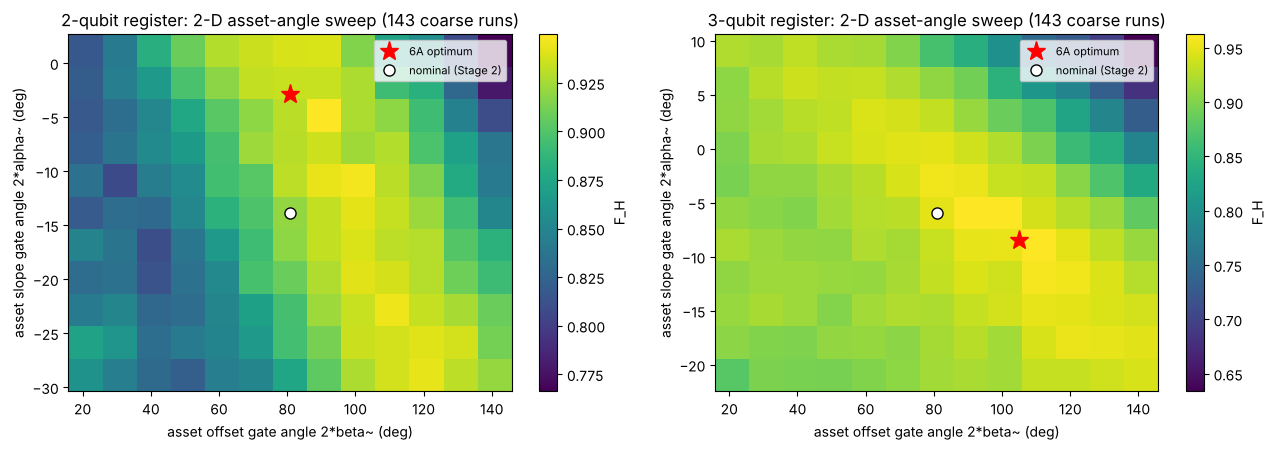

In [11]:
# The paper's Table 3 as a landscape: asset angles swept on the full GCI circuit
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, n in zip(axes, C.REGISTER_SIZES):
    g = gci[n][1]["grid"]
    land = g.extra["landscape"]
    a1, a2 = [2 * np.rad2deg(a) for a in land["coarse_axes"]]      # gate angles 2*beta, 2*alpha
    F = ((1 - land["coarse_distance"] ** 2) ** 2).reshape(len(a1), len(a2))
    im = ax.imshow(F.T, origin="lower", aspect="auto", cmap="viridis",
                   extent=[a1[0] - 5, a1[-1] + 5, a2[0] - 1.5, a2[-1] + 1.5])
    xb = 2 * np.rad2deg(g.x_best)
    ax.plot(xb[n], xb[n + 1], "r*", ms=14, label="6A optimum")
    x0 = 2 * np.rad2deg(gci[n][1]["x0"])
    ax.plot(x0[n], x0[n + 1], "wo", ms=8, mec="k", label="nominal (Stage 2)")
    plt.colorbar(im, ax=ax, label="F_H")
    ax.set_xlabel("asset offset gate angle 2*beta~ (deg)"); ax.set_ylabel("asset slope gate angle 2*alpha~ (deg)")
    ax.set_title(f"{n}-qubit register: 2-D asset-angle sweep ({g.extra['n_coarse']} coarse runs)")
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig(fig, "stage06_asset_landscape.png"); plt.show()

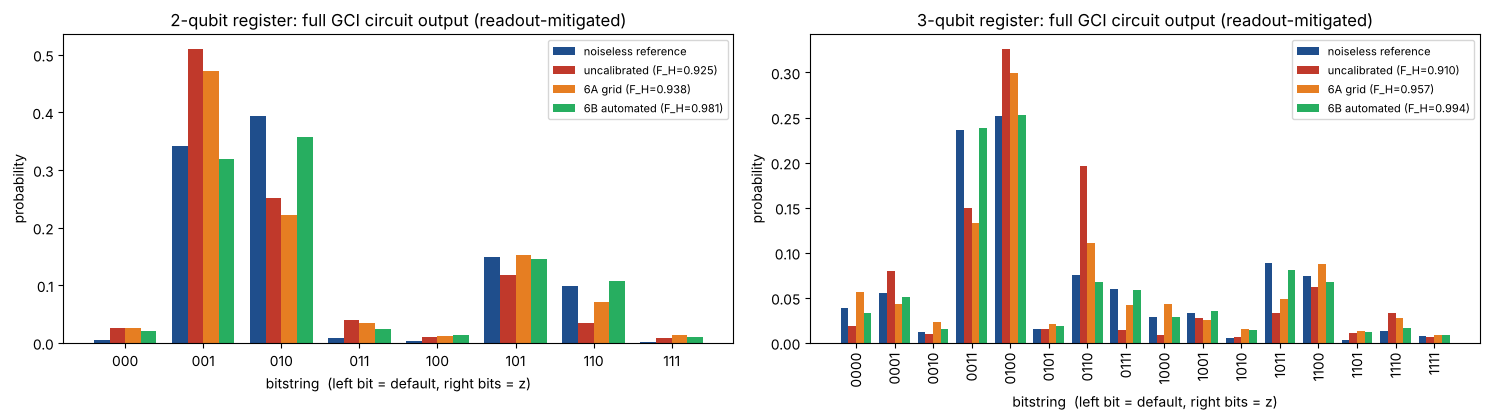

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
for ax, n in zip(axes, C.REGISTER_SIZES):
    summ, objs = gci[n]
    M, ref = objs["M"], objs["ref"]
    series = [("noiseless reference", ref, BLUE),
              ("uncalibrated", M.run(objs["x0"], 20000, seed=21), RED),
              ("6A grid", M.run(objs["grid"].x_best, 20000, seed=21), ORANGE),
              ("6B automated", M.run(objs["auto"].x_best, 20000, seed=21), GREEN)]
    k = np.arange(len(ref)); w = 0.2
    for i, (lab, p, c) in enumerate(series):
        f = "" if i == 0 else f" (F_H={hellinger_fidelity(p, ref):.3f})"
        ax.bar(k + (i - 1.5) * w, p, w, color=c, label=lab + f)
    ax.set_xticks(k); ax.set_xticklabels([format(i, f"0{n+1}b") for i in k], rotation=90 if n == 3 else 0)
    ax.set_title(f"{n}-qubit register: full GCI circuit output (readout-mitigated)")
    ax.set_xlabel("bitstring  (left bit = default, right bits = z)"); ax.set_ylabel("probability")
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig(fig, "stage06_gci_distributions.png"); plt.show()

 register | method                           | circuit runs |      shots |     F_H
----------------------------------------------------------------------------------
      2q  | uncalibrated (Stage 4)           |            0 |          0 |  0.9225
      2q  | 6A grid sweep (base paper)       |          347 |  1,388,000 |  0.9389
      2q  | 6B automated (this project)      |          204 |    816,000 |  0.9818
      2q  | ablation: joint SPSA             |          308 |  1,232,000 |  0.9820
      2q  | ablation: joint BO               |           70 |    280,000 |  0.9727
      3q  | uncalibrated (Stage 4)           |            0 |          0 |  0.9099
      3q  | 6A grid sweep (base paper)       |          477 |  1,908,000 |  0.9570
      3q  | 6B automated (this project)      |          204 |    816,000 |  0.9943
      3q  | ablation: joint SPSA             |          308 |  1,232,000 |  0.9469
      3q  | ablation: joint BO               |           70 |    280,000 |  0.9637


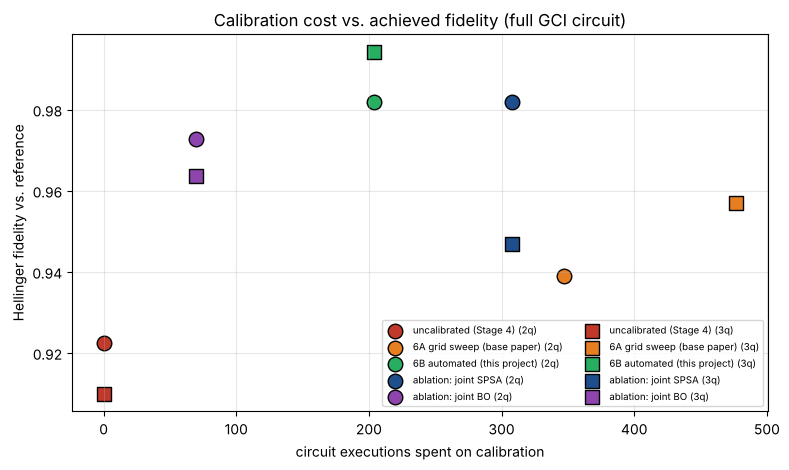

In [13]:
rows = []
for n in C.REGISTER_SIZES:
    summ = gci[n][0]
    rows.append((n, "uncalibrated (Stage 4)", 0, summ["uncalibrated"]["fidelity"]))
    for key, lab in [("grid_6A", "6A grid sweep (base paper)"), ("auto_6B", "6B automated (this project)"),
                     ("joint_spsa_ablation", "ablation: joint SPSA"), ("joint_bo_ablation", "ablation: joint BO")]:
        m = summ["methods"][key]
        rows.append((n, lab, m["n_evals"], m["fidelity"]))

print(f"{'register':>9} | {'method':32s} | {'circuit runs':>12} | {'shots':>10} | {'F_H':>7}")
print("-" * 82)
for n, lab, ev, f in rows:
    print(f"{n:>7}q  | {lab:32s} | {ev:>12d} | {ev * C.SHOTS_CALIBRATION:>10,d} | {f:7.4f}")

fig, ax = plt.subplots(figsize=(8, 4.8))
mk = {2: "o", 3: "s"}
col = {"uncalibrated (Stage 4)": RED, "6A grid sweep (base paper)": ORANGE, "6B automated (this project)": GREEN,
       "ablation: joint SPSA": BLUE, "ablation: joint BO": "#8e44ad"}
for n, lab, ev, f in rows:
    ax.scatter(ev, f, marker=mk[n], s=110, color=col[lab], edgecolor="k",
               label=f"{lab} ({n}q)")
ax.set_xlabel("circuit executions spent on calibration"); ax.set_ylabel("Hellinger fidelity vs. reference")
ax.set_title("Calibration cost vs. achieved fidelity (full GCI circuit)")
ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2, loc="lower right"); plt.tight_layout()
save_fig(fig, "stage06_cost_vs_quality.png"); plt.show()

In [14]:
results = {n: {"loader": loader[n][0], "gci": gci[n][0], "calibrated_parameters": params[n]}
           for n in C.REGISTER_SIZES}
path = save_stage06(results)
print(f"Saved -> {path}\n")
for n in C.REGISTER_SIZES:
    print(f"{n}-qubit register, commanded angles (deg)  [theta_0..theta_{n-1}, beta~, alpha~]:")
    for k, v in params[n].items():
        print(f"   {k:13s}: {np.round(np.rad2deg(v), 2)}")

Saved -> /home/claude/repo/results/stage06_retuning.json

2-qubit register, commanded angles (deg)  [theta_0..theta_1, beta~, alpha~]:
   uncalibrated : [ 90.   195.35  40.42  -6.93]
   grid_6A      : [ 90.   234.    40.42  -1.43]
   auto_6B      : [ 70.4  224.51  50.85  -6.82]
3-qubit register, commanded angles (deg)  [theta_0..theta_2, beta~, alpha~]:
   uncalibrated : [ 89.99  55.04 131.01  40.42  -2.97]
   grid_6A      : [ 89.99 256.5  198.    52.42  -4.22]
   auto_6B      : [115.01  34.37 109.92  55.32  -5.28]
